In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


### Business Understanding
The goal of this model is to predict binary diagnosis from breast cancer data. It is expected that the model is capable of predicting `(malignant, benign)`, based on the features listed in the next section `(base_features)`.

### Data understanding
The data consists of 10 base features, id, and the diagnosis column (maling / bening). The data is downloaded from archive.ics.uci.edu and the dataset states in the information that the data has not missing values. 

In [2]:
# load the training data and create a DataFrame
# name columns based on the features in the dataset

# base features in the dataset
base_features = [
    "radius", "texture", "perimeter", "area", "smoothness",
    "compactness", "concavity", "concave_points", "symmetry", "fractal_dimension",
]

# create a list of statistics for each feature
stats = ["mean", "se", "worst"]

# create a list of column names for the DataFrame
columns = ["id", "diagnosis"] + [f"{feat}_{stat}" for stat in stats for feat in base_features]

df = pd.read_csv("../datasets/bc/wdbc.data", header=None, names=columns)
df.head(10)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


### Data Preparation
First we split the data to X, which consists of all input features eg. radius, texture and y consists of all target variables (diagnosis). After splitting the data rougly 70/30 (training dataset/test dataset) using the hold-out validation technique, we proceed to scale the data using sklearn's built in StandardScaler feature. 

In [3]:
X = df.drop(columns=["id", "diagnosis"])  # input features
y = df["diagnosis"]  # target variable

# Dividing training set and validation set 70% - 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123)


In [ ]:
# Scale the input features using StandardScaler
scaler = StandardScaler()

# Scale the training and test sets separately
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

X_train_scaled.head(10)

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
559,-0.754501,1.016591,-0.731287,-0.732655,-0.244628,-0.046204,0.276113,-0.209613,-1.463648,0.393141,...,-0.786560,1.835601,-0.748038,-0.715894,-0.048296,0.013325,0.464941,-0.272555,-1.224122,0.246375
295,-0.107318,-1.377551,-0.167357,-0.212302,-0.290236,-0.806690,-0.982285,-0.780715,-0.758709,-0.498156,...,-0.330400,-1.399872,-0.391399,-0.384622,-0.624296,-0.968536,-1.127291,-0.871529,-0.081993,-0.899752
264,0.872048,0.598852,0.813064,0.791235,0.092006,-0.277838,0.018477,0.422567,0.191577,-0.947868,...,1.108900,0.583315,0.998261,0.988855,1.121705,0.047299,0.591565,1.311903,0.549310,-0.440828
125,-0.084408,-0.492662,-0.151531,-0.194880,-0.589225,-0.822895,-0.937614,-0.983264,-0.682686,-0.527956,...,-0.159600,-0.336308,-0.207531,-0.269767,-0.682796,-0.779638,-0.913008,-0.980094,-0.819317,-0.670290
280,1.436186,1.616250,1.421142,1.400153,0.435156,0.777386,1.288387,1.241373,0.312522,-0.080953,...,1.554646,1.634084,1.577161,1.499322,2.129706,0.912967,1.503354,1.137701,0.616777,0.830675
288,-0.826092,0.124964,-0.764607,-0.759951,-1.143042,0.258829,0.045129,0.177473,2.707241,-0.063344,...,-0.915701,-0.536226,-0.868317,-0.780766,-1.263297,-0.444650,-0.553915,-0.325282,0.130047,-0.772602
227,0.244911,-0.874467,0.223728,0.083300,-0.888938,0.096781,-0.301346,-0.294443,0.239955,-0.504929,...,0.032029,-1.019228,0.209397,-0.123893,-0.777296,0.767557,0.353473,0.370902,0.128441,0.027558
95,1.751187,0.814459,1.679367,1.766026,-0.377109,0.510482,0.717810,0.985317,0.979450,-0.854404,...,1.658792,0.944766,1.466180,1.545406,-0.534296,0.707762,0.693744,0.672645,1.309122,0.031106
20,-0.304909,-0.829548,-0.268565,-0.394368,0.833325,0.428504,-0.543716,-0.469324,0.537135,0.719588,...,-0.365809,-0.830506,-0.333809,-0.438859,0.014704,0.189312,-0.385735,-0.641179,0.497906,-0.078302
470,-1.282270,-0.205185,-1.273976,-1.064845,-0.472670,-0.799636,-0.746421,-0.885905,1.473598,0.180476,...,-1.065672,-0.010042,-1.089978,-0.873642,-0.336296,-0.649176,-0.685428,-0.753632,0.481842,0.123364


### Modeling
After data preparation, we proceeded to use the kNN-classifier machine learning method. We achieved a kNN-classifier accuracy of 99% using `n_neighbours = 3 (k)`. We tested different values from `1 - 15`, but we found out 3 to give the best accuracy readings.

In [5]:
# Create a kNN classifier
# n_neighbors parameter specifies the number of neighbors to use (k)
knn = KNeighborsClassifier(n_neighbors=3)

# Train the kNN classifier on the training data
knn.fit(X_train_scaled, y_train)

# Use the trained classifier to predict labels for the test set
y_pred = knn.predict(X_test_scaled)

# Calculate and print the accuracy of the classifier on the test set
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy of kNN classifier on the test set: {accuracy_test:.2f}")

Accuracy of kNN classifier on the test set: 0.99


### Evaluation
 We visualized the performance of the model using the confusion matrix. We tested the accuracy, recall and precision using sklearn's built in fatures. The model meets the business requirements as it predicts the diagnosis based on the 30 features inputted.

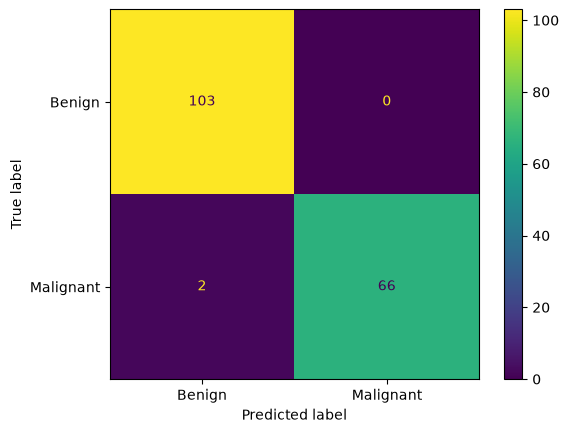

In [ ]:
# predict the labels for the test set using the trained kNN classifier
y_pred = knn.predict(X_test_scaled)

# form the confusion matrix using the true labels and predicted labels
cm = confusion_matrix(y_test, y_pred)
cmd = ConfusionMatrixDisplay(cm, display_labels=["Benign", "Malignant"])
cmd.plot()

In [24]:
# Calculate and print the accuracy of the classifier on the test set
accuracy_test = accuracy_score(y_test, y_pred)
# Ensure predictions are available for the test set
y_pred = knn.predict(X_test_scaled)

# Calculate and print the accuracy of the classifier on the test set
accuracy_test = accuracy_score(y_test, y_pred)
print(f"Accuracy of kNN classifier on the test set: {accuracy_test * 100:.2f}% or {accuracy_test:.2f}")

# Calculate and print the precision of the classifier on the test set
precision_test = precision_score(y_test, y_pred, pos_label='M')
print(f"Precision of kNN classifier on the test set: {precision_test * 100:.2f}% or {precision_test:.2f}")

# Calculate and print the recall of the classifier on the test set
recall_test = recall_score(y_test, y_pred, pos_label='M')
print(f"Recall of kNN classifier on the test set: {recall_test * 100:.2f}% or {recall_test:.2f}")


Accuracy of kNN classifier on the test set: 98.83% or 0.99
Precision of kNN classifier on the test set: 100.00% or 1.00
Recall of kNN classifier on the test set: 97.06% or 0.97


### Deployment
The madel can be used to predict a diagnosis of a breast tumor, the model is inputted data of 30 features of the tumor and it predicts if it is `bening or malignant`. The model outputs only a binary prediction. The accuracy, precision, and recall scores are high so the model can be used reliably to predict the diagnosis of the patient.


